#### 현재 위치 확인

In [18]:
%pwd

'c:\\Users\\ADMIN\\Documents\\projects\\team\\Dlthon_02\\Jong-ha'

#### 클라이언트 정의

In [19]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv()


openai_api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key = openai_api_key)

#### LLM 호출

In [20]:
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model = "gpt-5.4",
    temperature = 0.6,
    max_tokens = 1000
)

small_llm = ChatOpenAI(
    model = "gpt-5.4-mini",
    temperature = 0.6,
    max_tokens = 1000
)

#### 스테이트 정의

In [21]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState
import operator


class AgentState(MessagesState):
    
    # 공용
    response: str
    next: str
    reason: str

    # 기록관
    report: Annotated[list[str], operator.add]
    
    # 병인님
    ## 질병 관리
    breed: str
    age: int
    weight: int
    conditions: list[str]
    symptom_raw: str
    hospital: str

    ## 의도파악
    behavior: str
    behavior_cycle: int

    # 아인님 - 서비스 관련한 질문이 들어올 때
    latest_claim: str

#### 슈퍼바이저 노드

In [22]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


class SuperVisor(BaseModel):
    
    response_reason: str
    next_node: Literal["Agent1", "Agent2", "Agent3", "Agent4", "check_doc_relevance"] # = Field(description="다음 실행 노드를 결정")

router_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", """
            당신은 라우터 에이전트입니다.
            대화흐름을 검토하여 다음 사항을 수행하고 그 이유를 간단하게 명시하세요.
            1. 사용자가 반려동물의 상태나 건강에 대해서 물으면 check_doc_relevance 노드로 연결하세요.
            2. 사용자가 반려동물의 행동에 대해서 물으면 check_doc_relevance 노드로 연결하세요.
            3. 사용자가 서비스에 대해 물으면 check_doc_relevance 노드로 연결하세요.
            
            4. 사용자의 질문에 응답하기에 필요한 정보가 충분히 모였다고 판단된다면, check_doc_relevance 노드로 연결하세요.
            
            모든 결정에는 간단하고 짧게 이유를 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

supervisor_llm  = small_llm.with_structured_output(SuperVisor)
router_chain = router_prompt | supervisor_llm

def supervisor(state: AgentState) -> AgentState:
    response = router_chain.invoke({"messages": state["messages"]})
    
    # 몹시 중요한 부분, 랭그래프의 상태 관리 핵심 (왜 딕셔너리 전체를 리턴하지 않는데 스테이트가 이동하는지?)
    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

#### 문서 관련도 검증 노드

In [23]:
class DocRelevanceChecker(BaseModel):
    
    response_reason: str = Field(description="결정에 대한 이유를 명시하세요")
    next_node: Literal["supervisor", "final_agent"]


relevance_checker_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화의 흐름을 참고하여, 사용자의 질문과 검색된 문서가 관련이 있는지 검사하세요.
            2. 만약 관련이 전혀 없다면, 슈퍼바이저 노드로 연결하고 그렇게 판단한 이유를 간단히 명시하세요.
            3. 검색된 문서가 없는 경우, final_agent로 보내세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

relevance_checker_llm = small_llm.with_structured_output(DocRelevanceChecker)
relevance_checker_chain = relevance_checker_prompt | relevance_checker_llm

def check_doc_relevance(state: AgentState) -> AgentState:
    response = relevance_checker_chain.invoke({"messages": state["messages"]})

    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

#### 최종 답변 생성 노드

In [24]:
class FinalAnswer(BaseModel):
    
    response: str 
    response_reason: str = Field(description="답변 내용에 대한 이유를 명시하세요.")

final_answer_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화의 흐름을 참고하여, 사용자의 질문에 대한 최종 답변을 작성하세요.
            2. 답변 내용에 대한 이유를 간단히 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

final_answer_llm = llm.with_structured_output(FinalAnswer)
final_answer_chain = final_answer_prompt | final_answer_llm

def final_agent(state: AgentState) -> AgentState:
    response = final_answer_chain.invoke({"messages": state["messages"]})

    return {
        "response": response.response,
        "reason": response.response_reason
    }

#### 대화내용 기록 노드

In [29]:
class Recorder(BaseModel):
    
    report: list[str] = Field(description="의미있는 내용을 기록하세요.")

recorder_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화 내용을 참고하여 미래의 응답에 참고가 될 만한 의미있는 내용을 요약하여 기록하세요.
            2. 단, 이전 턴의 대화 기록에 있던 내용과 다소 중복되는 내용은 제외하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

recorder_llm = small_llm.with_structured_output(Recorder)
recorder_chain = recorder_prompt | recorder_llm

def recorder(state: AgentState) -> AgentState:
    response = recorder_chain.invoke({"messages": state["messages"]})

    return {
        "report": response.report
    }

#### 멀티턴 대화를 위한 인메모리 checkpoint (SqliteSaver)

In [34]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver


# 1. DB 연결 및 체크포인터 초기화
# 'checkpoints.sqlite' 파일이 자동으로 생성됩니다.
conn = sqlite3.connect("./data/checkpoints.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)

#### 노드를 엣지로 연결, 그래프 컴파일

In [35]:
from langgraph.graph import StateGraph, START, END


builder = StateGraph(AgentState)


builder.add_node("supervisor", supervisor)
builder.add_node("check_doc_relevance", check_doc_relevance)
builder.add_node("final_agent", final_agent)
builder.add_node("recorder", recorder)


builder.add_edge(START, "supervisor")
builder.add_edge("supervisor", "check_doc_relevance")

builder.add_conditional_edges(
    "check_doc_relevance", 
    lambda state: state["next"],
    {
        "supervisor": "supervisor",
        "final_agent": "final_agent"
    })
builder.add_edge("final_agent", "recorder")
builder.add_edge("recorder", END)


workflow = builder.compile(checkpointer=memory)

#### 그래프 도식화

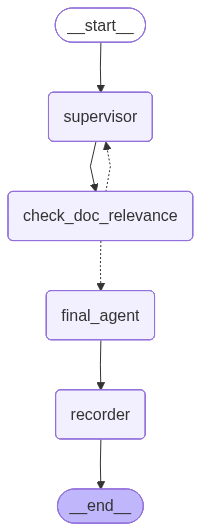

In [36]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [38]:
thread_id = "TEST-001"
config = {"configurable": {"thread_id": thread_id}}

print(f"대화를 시작합니다. Thread ID: {thread_id})")
print("대화를 종료하려면 'exit', 'quit'을 입력하세요.\n")

while True:
    query = input("[나]: " )

    if query.lower() in ["exit", "quit"]:
        print("에이전트: 즐거운 대화였습니다! 다음에 또 봐요.")
        break

    inputs = {"messages": [("user", query)]}
    print(f"[질문]: \n{inputs}\n")

    for output in workflow.stream(inputs, config=config):
        for key, value in output.items():
            print(f"\n[Node: {key}]")
            print(f"\n{value}")

대화를 시작합니다. Thread ID: TEST-001)
대화를 종료하려면 'exit', 'quit'을 입력하세요.

[질문]: 
{'messages': [('user', '안녕 오늘 날씨 좋지않아?')]}


[Node: supervisor]

{'next': 'Agent1', 'reason': '반려동물 상태/행동/서비스 관련 질문이 아니므로 일반 대화에 해당합니다.'}

[Node: check_doc_relevance]

{'next': 'final_agent', 'reason': '검색된 문서가 제공되지 않았으므로 관련성 검사를 수행할 대상이 없습니다. 사용자 질문은 일반적인 안부/날씨 대화로 보입니다.'}

[Node: final_agent]

{'response': '안녕하세요! 저는 실시간 날씨를 직접 확인할 수는 없지만, 오늘 하늘이 맑거나 기분 좋은 날씨였으면 좋겠네요. 혹시 계신 지역을 알려주시면 날씨 확인 방법이나 옷차림 추천은 도와드릴게요!', 'reason': '실시간 위치·날씨 정보에 접근할 수 없어서 현재 날씨를 단정할 수는 없기 때문입니다. 대신 자연스럽게 대화를 이어가고, 사용자가 지역을 알려주면 도움이 될 수 있는 방향으로 답변했습니다.'}

[Node: recorder]

{'report': ['사용자는 한국어로 짧고 친근한 대화를 선호하는 듯하다.']}
[질문]: 
{'messages': [('user', '흠 그런가.. 알았어 근데 넌 누구야?')]}


[Node: supervisor]

{'next': 'Agent1', 'reason': '사용자가 제 정체를 물었으며, 반려동물 상태/행동/서비스 관련 질문은 아닙니다. 추가 정보 없이도 답변 가능하므로 별도 문서 확인보다 일반 응답 노드로 연결합니다.'}

[Node: check_doc_relevance]

{'next': 'final_agent', 'reason': '검색된 문서가 제공되지 않았고, 사용자의 질문은 문서 관련성 판단이 필요한 상황이 아니라 일반 대화입니